# TEC Driver Control Analysis

This notebook derives the simplified closed-loop transfer function for the TEC temperature-control system, and test if this system is within conversion.

In [7]:
import sympy as sp
from IPython.display import display, Math

s = sp.symbols("s")

# Hyperparameters
Cth, Kleak, Kp, Ki = sp.symbols("C_th K_leak K_p K_i", positive=True)

# differential variables
Tsample, Tset, Tenv = sp.symbols("T_sample T_set T_env")
E, Dpwm, Itec, Qc = sp.symbols("E D_PWM I_TEC Q_c")

# Define Error equation:
eq_error = sp.Eq(E, Tsample - Tset)

# Define PI controller in s-domain:
eq_controller = sp.Eq(Dpwm, (Kp + Ki/s) * E)

# Define Actuator equation:
eq_actuator = sp.Eq(Itec, 3.81 * Dpwm)

# Define Simplified TEC cooling equation:
eq_cooling = sp.Eq(Qc, 3.5 * Itec)

# Thermal plant equation in s-domain:
# C_th * dT_sample/dt = K_leak(T_env - T_sample) - Q_c
# Laplace transform:
# C_th * s * T_sample = K_leak(T_env - T_sample) - Q_c
eq_thermal = sp.Eq(Cth * s * Tsample, Kleak * (Tenv - Tsample) - Qc)

## Substitute equations step by step

# Substitute error into controller
Dpwm_expr = eq_controller.rhs.subs(E, eq_error.rhs)

# Substitute D_PWM into I_TEC
Itec_expr = eq_actuator.rhs.subs(Dpwm, Dpwm_expr)

# Substitute I_TEC into Q_c
Qc_expr = eq_cooling.rhs.subs(Itec, Itec_expr)

# Substitute Q_c into thermal equation
thermal_sub = eq_thermal.subs(Qc, Qc_expr)

## Solve for T_sample(s) in terms of T_set(s) and T_env(s)
solution_Tsample = sp.solve(thermal_sub, Tsample)[0]
solution_Tsample = sp.simplify(solution_Tsample)

display(Math(r"T_{sample}(s) = " + sp.latex(solution_Tsample)))

##  Transfer function T_sample(s) / T_set(s)
solution_no_env = solution_Tsample.subs(Tenv, 0)

G_closed = sp.simplify(solution_no_env / Tset)

display(Math(r"\frac{T_{sample}(s)}{T_{set}(s)} = " + sp.latex(G_closed)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
# Get numerator and denominator from Transfer function
num, den = sp.fraction(sp.factor(G_closed))

# Solve poles from denominator = 0
poles_symbolic = sp.solve(den, s)

display(Math(r"\text{Symbolic poles:}"))

for i, p in enumerate(poles_symbolic, start=1):
    display(Math(r"s_{} = {}".format(i, sp.latex(p))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
num, den = sp.fraction(sp.factor(G_closed))

display(Math(r"\text{Denominator: }" + sp.latex(den)))

<IPython.core.display.Math object>

In [10]:
# Get polynomial coefficients of denominator: a*s^2 + b*s + c
poly = sp.Poly(den, s)

a = poly.coeff_monomial(s**2)
b = poly.coeff_monomial(s)
c = poly.coeff_monomial(s**0)

display(Math(r"a = " + sp.latex(a)))
display(Math(r"b = " + sp.latex(b)))
display(Math(r"c = " + sp.latex(c)))

# Repeated pole condition: discriminant = 0
discriminant = sp.simplify(b**2 - 4*a*c)

display(Math(r"\Delta = b^2 - 4ac = " + sp.latex(discriminant)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
Ki_solution = sp.solve(sp.Eq(discriminant, 0), Ki)[0]

display(Math(r"K_i = " + sp.latex(Ki_solution)))

<IPython.core.display.Math object>

In [18]:
B = sp.Rational(2667, 200)   # 13.335 exactly, I found this value is actually the cooling gain!

den_clean = Cth*s**2 + (Kleak + B*Kp)*s + B*Ki

omega_n = sp.symbols(r"\omega_n", positive=True)

desired_den = Cth * (s + omega_n)**2

actual_poly = sp.Poly(den_clean, s)
desired_poly = sp.Poly(sp.expand(desired_den), s)

eq_s1 = sp.Eq(actual_poly.coeff_monomial(s), desired_poly.coeff_monomial(s))
eq_s0 = sp.Eq(actual_poly.coeff_monomial(s**0), desired_poly.coeff_monomial(s**0))

solution_Kp_Ki = sp.solve([eq_s1, eq_s0], [Kp, Ki], dict=True)[0]

display(Math(r"K_p = " + sp.latex(solution_Kp_Ki[Kp])))
display(Math(r"K_i = " + sp.latex(solution_Kp_Ki[Ki])))

cooling_gain = sp.Rational(2667, 200)  # 13.335


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Estimated parameters
Cth_val = 200.0
Kleak_val = 0.2

# cooling gain = 2667/200
cooling_gain = 13.335

# Desired settling time
Ts_val = 120.0
omega_n_val = 4 / Ts_val

# PI gains Kp and Ki
Kp_val = (2 * Cth_val * omega_n_val - Kleak_val) / cooling_gain
Ki_val = (Cth_val * omega_n_val**2) / cooling_gain

print("omega_n =", omega_n_val)
print("Kp =", Kp_val)
print("Ki =", Ki_val)

omega_n = 0.03333333333333333
Kp = 0.9848768903887014
Ki = 0.01666458359371745


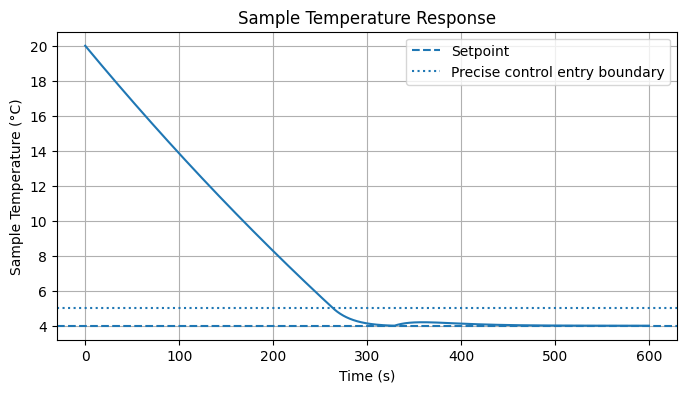

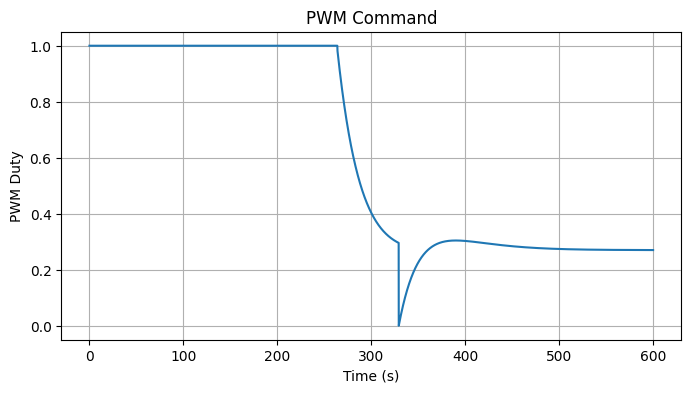

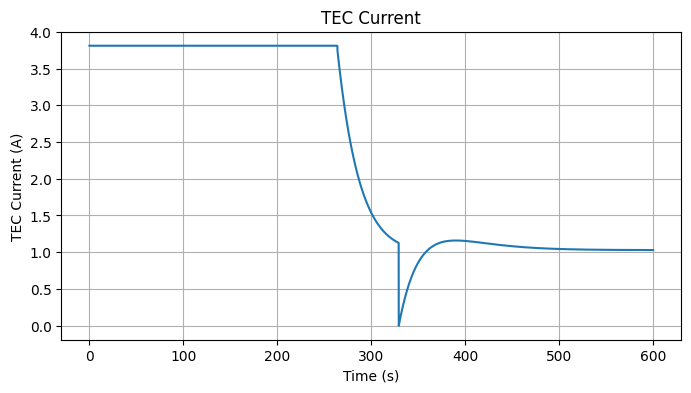

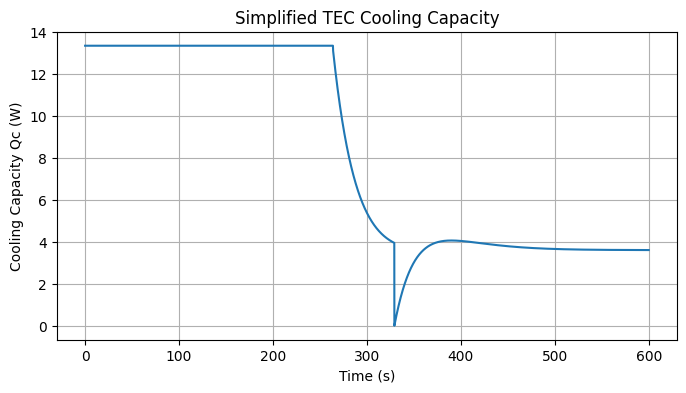

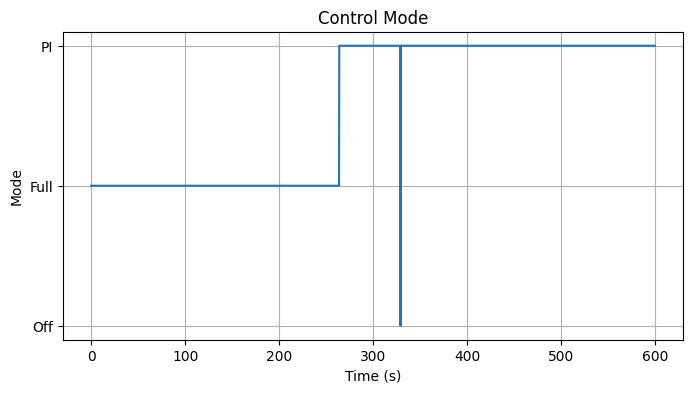

In [42]:
# time domain simulation of the closed-loop system with the designed PI controller
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
t_end = 600
t = np.arange(0, t_end, dt)

T_set = 4.0
T_env = 22.0
T_sample = 20.0

# Switch to PI when sample is close enough to target
T_band_high = 1.0   # start PI when T_sample <= T_set + 5°C
T_band_low = 0.0    # shut off if below target

integral_error = 0.0

T_log = []
D_log = []
I_log = []
Qc_log = []
mode_log = []

for ti in t:
    e = T_sample - T_set

    if T_sample < T_set + T_band_low:
        # Too cold: turn TEC off and reset integral to avoid windup
        D_pwm = 0.0
        integral_error = 0.0
        mode = 0  # off

    elif T_sample > T_set + T_band_high:
        # Far above target: full cooling
        D_pwm = 1.0
        mode = 1  # full drive

    else:
        # Near target: PI control
        integral_error += e * dt
        D_pwm = Kp_val * e + Ki_val * integral_error
        D_pwm = max(0.0, min(1.0, D_pwm))
        mode = 2  # PI

    I_tec = 3.81 * D_pwm
    Qc = cooling_gain * D_pwm

    Qleak = Kleak_val * (T_env - T_sample)
    dTdt = (Qleak - Qc) / Cth_val

    T_sample += dTdt * dt

    T_log.append(T_sample)
    D_log.append(D_pwm)
    I_log.append(I_tec)
    Qc_log.append(Qc)
    mode_log.append(mode)

plt.figure(figsize=(8, 4))
plt.plot(t, T_log)
plt.axhline(T_set, linestyle="--", label="Setpoint")
plt.axhline(T_set + T_band_high, linestyle=":", label="Precise control entry boundary")
plt.xlabel("Time (s)")
plt.ylabel("Sample Temperature (°C)")
plt.title("Sample Temperature Response")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, D_log)
plt.xlabel("Time (s)")
plt.ylabel("PWM Duty")
plt.title("PWM Command")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, I_log)
plt.xlabel("Time (s)")
plt.ylabel("TEC Current (A)")
plt.title("TEC Current")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, Qc_log)
plt.xlabel("Time (s)")
plt.ylabel("Cooling Capacity Qc (W)")
plt.title("Simplified TEC Cooling Capacity")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, mode_log)
plt.yticks([0, 1, 2], ["Off", "Full", "PI"])
plt.xlabel("Time (s)")
plt.ylabel("Mode")
plt.title("Control Mode")
plt.grid(True)
plt.show()